# Anomaly detection via principal component analysis

In this notebook we illustrate how PCA can be employed for anomaly detection in structural health monitoring. A synthetic dataset of strain fields is generated to represent a plate subjected to tensile loading under healthy and damaged conditions. The PCA basis is identified from healthy measurements only, and new observations are subsequently classified according to their reconstruction error.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans

### Generate synthetic strain fields

Each sample represents a strain field measured on a plate subjected to uniaxial tension of variable intensity. Healthy samples exhibit smooth spatial variations due to changes in the applied load, whereas damaged samples feature an additional localized strain concentration that reflects the effect of a defect such as a crack.

Each strain field is discretized on a spatial grid and flattened into a vector. Consequently, each data sample contains hundreds of features, making the dataset high-dimensional. PCA is here used to identify a low-dimensional representation of these strain fields.

In [2]:
np.random.seed(42)

# Spatial grid defining the plate domain
nx, ny = 40, 20 # Number of columns and rows defining the spatial grid 
x = np.linspace(0, 1, nx) # Columns distributed along the width of the plate
y = np.linspace(0, 0.5, ny) # Rows distributed along the height of the plate
X, Y = np.meshgrid(x, y) # x and y coordinates of the plate grid cells as (ny, nx) tables

# Generate sufficiently many realizations to obtain stable PCA modes
N_h_train = 1000 # Healthy training samples
N_h_test = 500 # Healthy testing samples
N_d_test = 500 # Damaged testing samples

# Container for the vectorized strain fields
strain_fields = []

# Generation of healthy samples (both training and testing)
# Healthy structures exhibit smooth strain distributions that increase gradually along the member length
for _ in range(N_h_train+N_h_test):

    # Variable load
    load = np.random.uniform(0.8, 1.2)

    # Baseline strain field - assume traction load linearly increase along the plate width
    eps = load * (1 + 0.3 * X)

    # Add Gaussian measurement noise to mimic sensor uncertainty
    eps += 0.08 * np.random.randn(*eps.shape)

    strain_fields.append(eps.flatten())

# Generation of damaged samples
# Damaged structures features a random localized strain concentration that mimic stiffness reductions caused by cracks
for _ in range(N_d_test):

    # Variable load
    load = np.random.uniform(0.8, 1.2)

    # Baseline strain field - assume traction load linearly increase along the plate width
    eps = load * (1 + 0.3 * X)

    # Random damage location
    xd = np.random.uniform(0.3, 0.8) # Along the width
    yd = np.random.uniform(0.1, 0.4) # Along the height

    damage_size = 0.04

    # Local strain concentration representing damage
    damage = np.exp(-((X - xd)**2 + (Y - yd)**2) # Mostly zero contribution, except around the damage location
                    /(2 * damage_size**2))       # Damage_size controls the spread of values different from zero

    # Random damage severity controlling the amplitude of the strain concentration
    severity = np.random.uniform(0.4,0.6)
    eps += severity * damage # Add strain concentration due to damage to the baseline strain field

    # Add Gaussian measurement noise to mimic sensor uncertainty
    eps += 0.08 * np.random.randn(*eps.shape)

    strain_fields.append(eps.flatten())

# Matrix of observations
X_data = np.array(strain_fields)
print(X_data.shape)

(2000, 800)


### Visualize healthy vs damaged samples

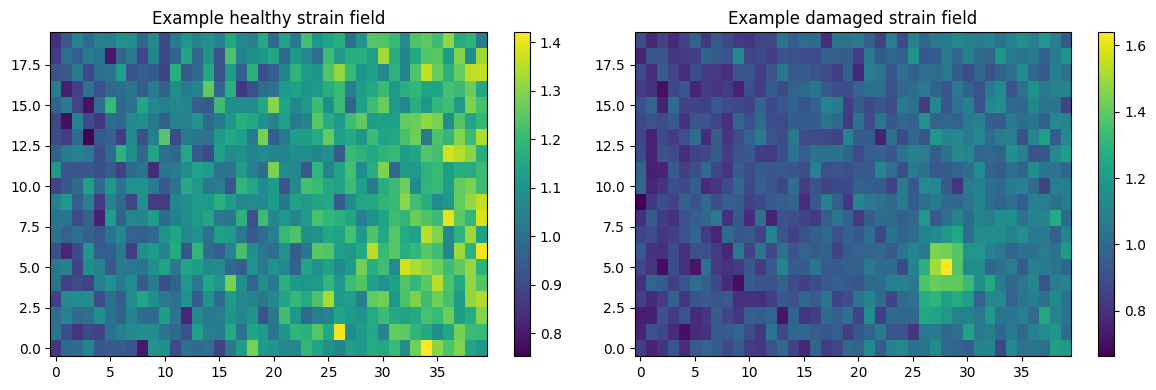

In [3]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

healthy = X_data[0].reshape(ny,nx)
damaged = X_data[-1].reshape(ny,nx)

im0 = ax[0].imshow(healthy, origin="lower", aspect="auto")

ax[0].set_title("Example healthy strain field")
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(damaged, origin="lower", aspect="auto")

ax[1].set_title("Example damaged strain field")
plt.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()

### Principal component analysis

PCA is sensitive to the relative scale of the input variables; data standardization is therefore required to prevent variables with large numerical ranges from dominating the analysis. In our example, standardization ensures that all sensor locations contribute comparably to the analysis. The standardization parameters are estimated using only the training data and are then applied unchanged to the testing set.

The principal components are also computed exclusively from the healthy training data, defining a low-dimensional representation that is appropriate only for the undamaged structural behavior. If damaged samples are projected onto this low-dimensional space, important features associated with the damage may not be well represented and may therefore be lost.

In [4]:
X_h_train = X_data[:N_h_train] # Extract healthy training samples 
X_h_test = X_data[N_h_train:N_h_train+N_d_test] # Extract damaged testing samples
X_d_test = X_data[N_h_train+N_d_test:] # Extract healthy testing samples

scaler = StandardScaler()
# The scaler is fitted using training data only
X_h_train_scaled = scaler.fit_transform(X_h_train)
# The same transformation is subsequently applied to the test set
X_h_test_scaled  = scaler.transform(X_h_test)
X_d_test_scaled  = scaler.transform(X_d_test)

# Normal behavior is learned from healthy training data only
pca_h = PCA(n_components=5) # Number of retained principal components → try different values
Z_train_h = pca_h.fit_transform(X_h_train_scaled)

# Project the testing samples (both healthy and damaged) onto the PCA subspace
Z_test_h = pca_h.transform(X_h_test_scaled) 
Z_test_d = pca_h.transform(X_d_test_scaled) 

# Reconstruct the training and testing samples (both healthy and damaged) from their reduced representation
X_h_train_rec = pca_h.inverse_transform(Z_train_h)
X_h_test_rec = pca_h.inverse_transform(Z_test_h)
X_d_test_rec = pca_h.inverse_transform(Z_test_d)

### Anomaly detection via reconstruction error

Healthy strain fields can be accurately reconstructed because they are well described by the low-dimensional subspace identified during training. Conversely, damaged strain fields contain localized patterns that cannot be represented by the healthy PCA basis, leading to larger reconstruction errors.

In [5]:
# Reconstruction error for the healthy training data
error_train_h = np.linalg.norm(X_h_train_scaled - X_h_train_rec, axis=1)
# Reconstruction error for the healthy testing data
error_test_h = np.linalg.norm(X_h_test_scaled - X_h_test_rec, axis=1)
# Reconstruction error for the damaged testing data
error_test_d = np.linalg.norm(X_d_test_scaled - X_d_test_rec, axis=1)

# Reconstruction errors can be standardized, again with statistics from the (healthy) training data only
scaler_err = StandardScaler()
scaler_err.fit_transform(error_train_h.reshape(-1, 1))
# The same transformation is subsequently applied to the test set
error_test_h_scaled = scaler_err.transform(error_test_h.reshape(-1, 1))
error_test_d_scaled = scaler_err.transform(error_test_d.reshape(-1, 1))

### Visualize the Distributions of the Reconstruction Errors for the Healthy and Damaged Testing Data

We expect to observe:
- the distribution of reconstruction errors for the healthy testing data to be centered around zero
- the distribution of reconstruction errors for the damaged testing data to be shifted away from zero and to exhibit greater variability

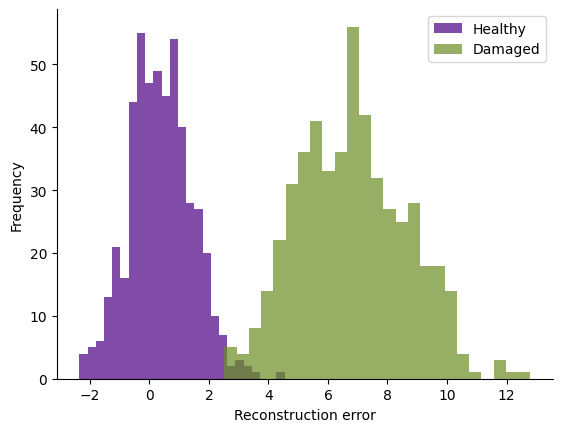

In [6]:
plt.figure()

plt.hist(error_test_h_scaled,
        bins=25, alpha=0.7, label="Healthy", color='indigo')

plt.hist(error_test_d_scaled,
        bins=25, alpha=0.7, label="Damaged", color='olivedrab')

plt.xlabel("Reconstruction error")
plt.ylabel("Frequency")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend()
plt.show()

### Anomaly detection model

In statistics, an outlier (or anomaly) is a data point that differs significantly from the normal behavior of the system. However, an anomaly does not necessarily indicate structural damage. Consequently, an inappropriate characterization of the normal operating condition can have serious consequences: data from an undamaged structure may be incorrectly flagged as damaged (false alarms), while data from a damaged structure may remain undetected (missed detections). How can we make the anomaly detection process more robust?

An anomaly detection model can be obtained by statistically characterizing the reconstruction errors of the healthy samples. Since the reconstruction model is trained exclusively on healthy data, damaged samples which are not represented by the learned principal components are expected to produce larger reconstruction errors than those typically observed for healthy samples.

Assuming that the reconstruction errors follow a Gaussian distribution, they can be characterized by two parameters:

- Mean
- Standard deviation

The reconstruction errors are normalized using the mean and standard deviation estimated from the healthy training data (the baseline condition). This produces dimensionless z-scores that quantify how abnormal each testing sample is relative to normal operating conditions. A statistical distance can then be used to assess the condition of a new observation.

The z-score measures the statistical distance of a reconstruction error from a Gaussian distribution with mean $\mu_\epsilon$ and standard deviation $\sigma_\epsilon$:
$$z_\epsilon = \frac{\epsilon-\mu_\epsilon}{\sigma_\epsilon}.$$

A decision threshold is then defined as:
$$z^*_\epsilon = \mu_{z_\epsilon}\pm\alpha\sigma_{z_\epsilon}=\pm\alpha,$$
since the normalized healthy data have $\mu_{z_\epsilon}=0$ and $\sigma_{z_\epsilon}=1$.

Typical choices are:
- $\alpha = 2$: approximately 5\% probability of false alarms rate
- $\alpha = 3$: approximately 0.3% probability of false alarms rate

If $|z_\epsilon| > \alpha$, the observation is classified as an anomaly.

In [7]:
# Setting the threshold
threshold = 2

# Apply detection model for the healthy testing data
predicted_damage_h = np.abs(error_test_h_scaled) > threshold
print("Detected false anomalies:", predicted_damage_h.sum())

# Apply detection model for the damaged testing data
predicted_damage_d = np.abs(error_test_d_scaled) > threshold
print("Detected true anomalies:", predicted_damage_d.sum())

Detected false anomalies: 36
Detected true anomalies: 500


### Visualize $z_\epsilon$ scores for the testing samples

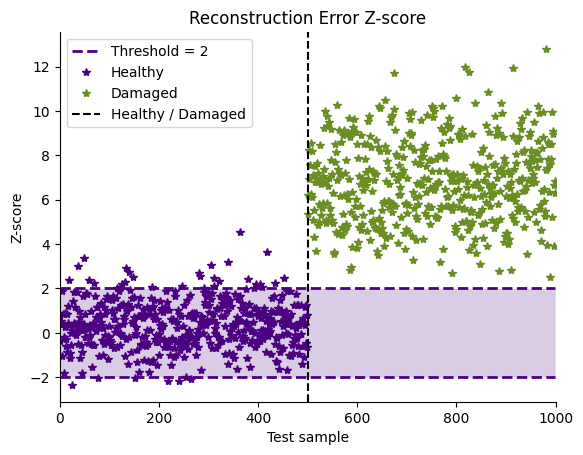

In [8]:
plt.plot(np.arange(N_h_test+N_d_test),threshold*np.ones((N_h_test+N_d_test)),
         '--',color='indigo', alpha=1, linewidth=2)
plt.plot(np.arange(N_h_test+N_d_test),-threshold*np.ones((N_h_test+N_d_test)),
         '--',color='indigo', alpha=1, linewidth=2, label=f'Threshold = {threshold}')

plt.fill_between(np.arange(N_h_test+N_d_test),
                 -threshold*np.ones((N_h_test+N_d_test)),
                 threshold*np.ones((N_h_test+N_d_test)),
                 alpha=0.2, linewidth=0, color='indigo')

plt.plot(np.arange(N_h_test),error_test_h_scaled,
         '*',label='Healthy', color='indigo')
plt.plot(np.arange(N_h_test, N_h_test+N_d_test),error_test_d_scaled,
         '*',label='Damaged', color='olivedrab')

plt.axvline(N_h_test,
            color='k', linestyle='--', label='Healthy / Damaged')

plt.xlim(0, N_h_test+N_d_test)

plt.xlabel("Test sample")
plt.ylabel("Z-score")
plt.title("Reconstruction Error Z-score")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend()
plt.show()

### Detection results (confusion matrix)

The performance of an anomaly detection model can be evaluated by comparing its predictions with the true condition of the structure. A convenient way to summarize the classification results is through the confusion matrix, which reports the number of correctly and incorrectly classified samples.

For a binary classification problem, such as distinguishing between healthy and damaged conditions, the confusion matrix consists of four possible outcomes:
- True Positive (TP): a damaged sample is correctly classified as damaged.
- True Negative (TN): a healthy sample is correctly classified as healthy.
- False Positive (FP): a healthy sample is incorrectly classified as damaged (false alarm).
- False Negative (FN): a damaged sample is incorrectly classified as healthy (missed detection).
  
In structural health monitoring, false positives may lead to unnecessary inspections, while false negatives are generally more critical since they correspond to damaged structures that remain undetected. Several performance metrics can be derived from the confusion matrix. The most common are:
- Accuracy: the proportion of correctly classified samples
$$\mathrm{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN}$$
- Precision: the proportion of predicted damaged samples that are actually damaged
$$\mathrm{Precision}=\frac{TP}{TP+FP}$$
- Recall (sensitivity): the proportion of damaged samples that are correctly identified
$$\mathrm{Recall}=\frac{TP}{TP+FN}$$
- Specificity: the proportion of healthy samples that are correctly identified
$$\mathrm{Specificity}=\frac{TN}{TN+FP}$$

A reliable anomaly detection model should achieve a high recall to minimize missed detections while maintaining a high specificity to reduce the number of false alarms.

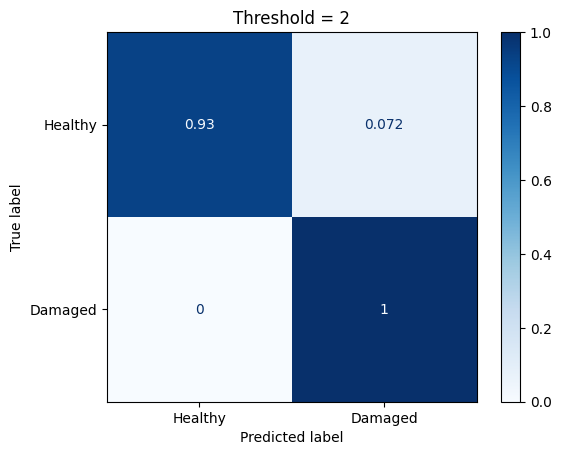

In [9]:
cm = confusion_matrix(np.concatenate((np.zeros((N_h_test)),np.ones((N_d_test)))), 
                      np.concatenate((predicted_damage_h,predicted_damage_d)), normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Damaged"])
disp.plot(cmap='Blues')
plt.title(f"Threshold = {threshold}")
plt.show()

### Receiver Operating Characteristic (ROC) curve

The threshold can be adjusted to obtain the desired performance as a tradeoff between:

-  Probability of detection (POD), which is the recall metric
-  False alarm rate: FP / (FP + TN)

Varying the detection threshold produces different operating points. The resulting Receiver Operating Characteristic (ROC) curve summarizes the trade-off between sensitivity and false-alarm rate independently of a specific threshold.

POD = 1.000
FA  = 0.942


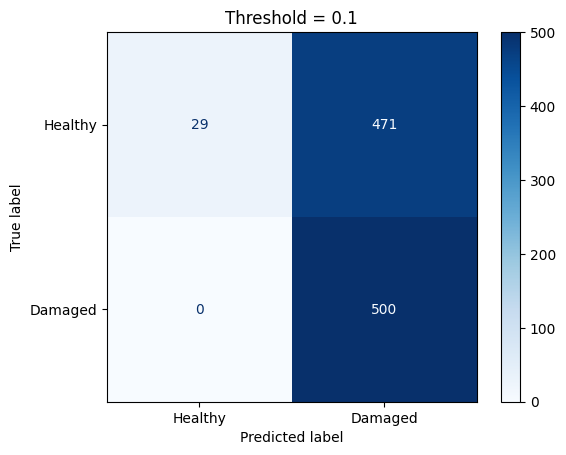

POD = 1.000
FA  = 0.640


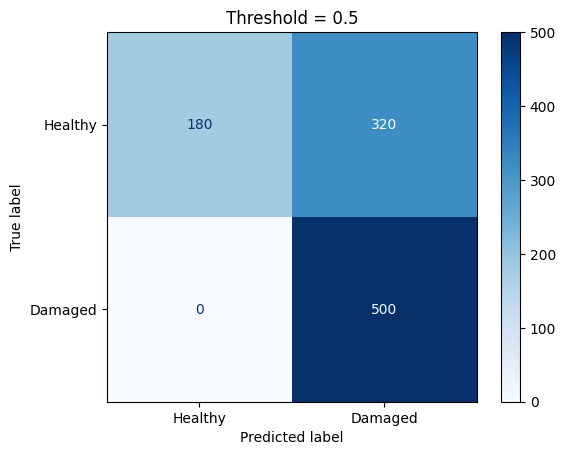

POD = 1.000
FA  = 0.360


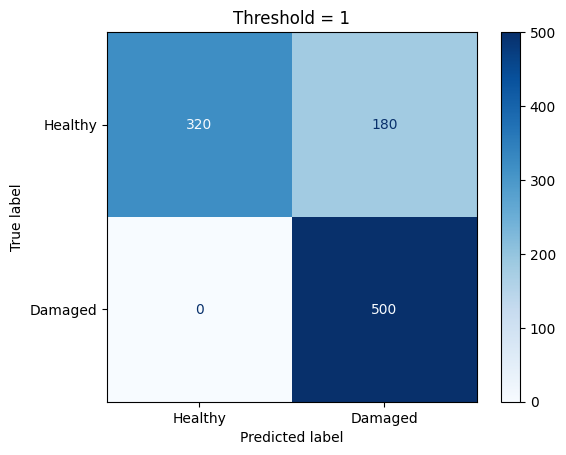

POD = 1.000
FA  = 0.072


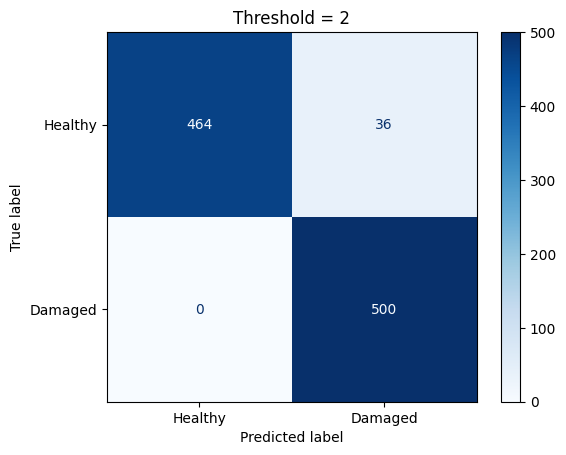

POD = 0.988
FA  = 0.012


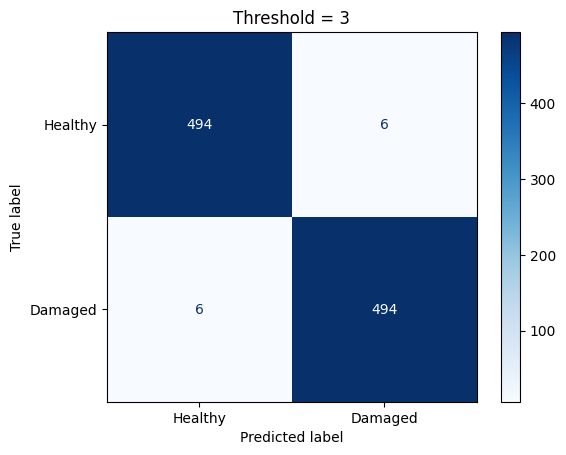

POD = 0.828
FA  = 0.000


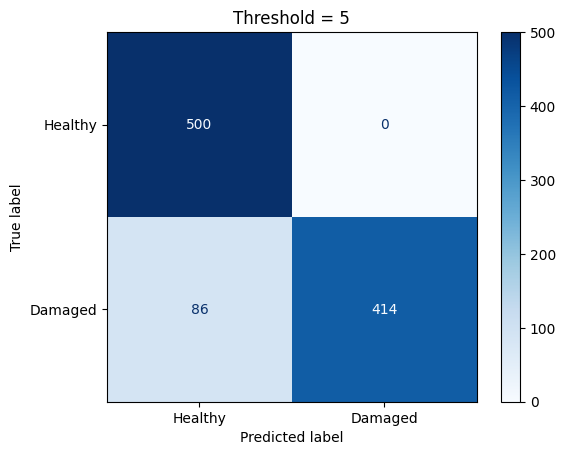

POD = 0.040
FA  = 0.000


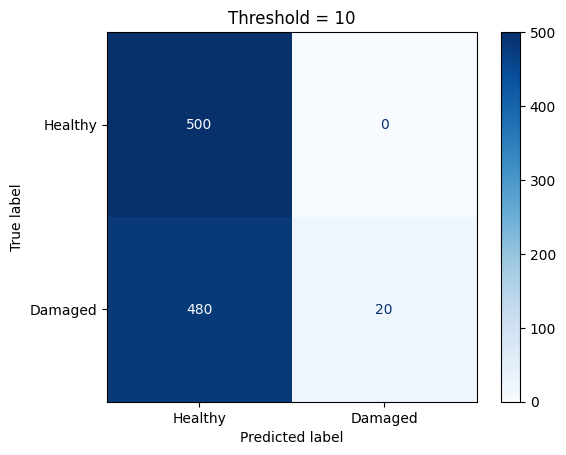

In [10]:
POD = [] # Probability of detection
FA = [] # False alarm rate

thresholds = [0.1, 0.5, 1, 2, 3, 5, 10]

# Repeat detection analysis for each threshold value and store POD and FA
for threshold in thresholds:

    predicted_damage_h = np.abs(error_test_h_scaled) > threshold
    predicted_damage_d = np.abs(error_test_d_scaled) > threshold
    
    # Confusion matrix
    cm = confusion_matrix(np.concatenate((np.zeros((N_h_test)),np.ones((N_d_test)))), 
                      np.concatenate((predicted_damage_h,predicted_damage_d)))

    tn, fp, fn, tp = cm.ravel()
    pod = tp / (tp + fn)
    far = fp / (fp + tn)

    POD.append(pod)
    FA.append(far)

    print(f"POD = {pod:.3f}")
    print(f"FA  = {far:.3f}")
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Damaged"])
    disp.plot(cmap='Blues')
    plt.title(f"Threshold = {threshold}")
    plt.show()

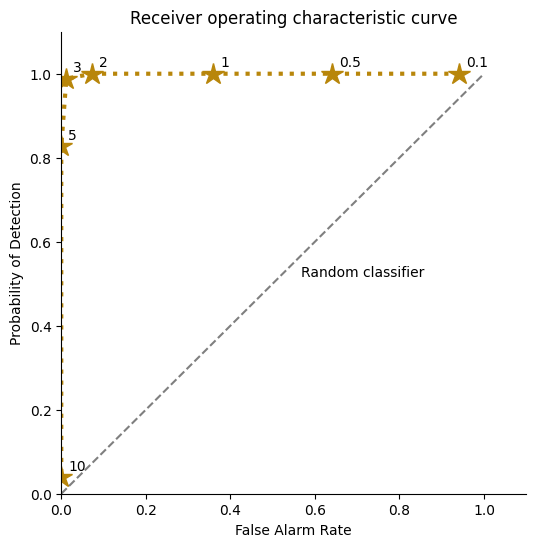

In [11]:
plt.figure(figsize=(6,6))

plt.plot(FA, POD, ':*', ms=16, color='darkgoldenrod', linewidth=3)

for th, fa, pod in zip(thresholds, FA, POD):
    plt.annotate(f'{th}',(fa, pod),
                xytext=(5,5), textcoords='offset points')

plt.plot([0,1], [0,1], 'k--', alpha=0.5)

plt.annotate('Random classifier',(0.55, 0.5),
            xytext=(5,5), textcoords='offset points')

plt.xlabel("False Alarm Rate")
plt.ylabel("Probability of Detection")
plt.title("Receiver operating characteristic curve")

plt.ylim(0, 1.1)
plt.xlim(0, 1.1)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

Remarks:

- Learn the PCA basis from healthy data only
- Project new measurements onto the reduced feature space
- Reconstruct the measurements using the retained principal components
- Use the reconstruction error as an anomaly indicator
- Classify observations by comparing the anomaly score with a detection threshold
- The analysis can be repeated changing the number of retained principal components, what can be concluded in this respect?
- The same methodology can be directly applied to experimental strain, displacement, vibration, or modal-shape measurements